# Fringe Projection: Perspective Correction

This notebook demonstrates the **perspective effect** in fringe projection profilometry
and how a custom pre-deformed grating corrects it.

We compare three cases:
1. **Ideal (no angle)** -- fringes projected normal to the surface, constant period
2. **Uncorrected (at angle)** -- fringes projected at angle theta, perspective distortion
3. **Corrected (custom grating at angle)** -- variable period p2(x1) compensates for the angle

Videos are rendered with PyVista and exported as .mp4 files.

Reference: Dr. Ayman Samara, *Fringe Projection System*

In [86]:
import numpy as np
import imageio.v3 as iio
from pathlib import Path

output_dir = Path('videos')
output_dir.mkdir(exist_ok=True)

## System Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| l | 128 mm | Lens-to-surface distance |
| a | 128 mm | Grating-to-lens distance |
| theta | 20 deg | Projection/viewing angle |
| p | 1 mm | Grating period |
| FOV | 12 mm | Field of view |

In [87]:
# System geometry (symmetric)
a = 128.0        # mm
l = 128.0        # mm
theta = np.radians(20)  # projection angle
p = 1.0          # mm, grating period
FOV = 12.0       # mm
M = l / a

# Grid
Nx, Ny = 640, 480
N_steps = 64
delta = 2 * np.pi / N_steps

x1_mm = np.linspace(-FOV / 2, FOV / 2, Nx)
y_mm = np.linspace(-FOV * Ny / (2 * Nx), FOV * Ny / (2 * Nx), Ny)
X1, Y = np.meshgrid(x1_mm, y_mm)

A, B = 0.5, 0.5  # intensity offset and modulation

print(f'theta {np.degrees(theta):.1f} deg')
print(f'perspective factor range: {1 - 2*x1_mm[-1]*np.tan(theta)/a:.4f} to {1 - 2*x1_mm[0]*np.tan(theta)/a:.4f}')

theta 20.0 deg
perspective factor range: 0.9659 to 1.0341


## Compute Fringe Phases

**Uncorrected** (Eq 2-26): phi = (2pi/p) * [1 - 2*x1*tan(theta)/a] * x1

**Custom grating** (Eq 2-36): p2 = p * (1 - 2*x1*tan(theta)/a)

Projected through perspective: phi = (2pi/p2) * [1 - 2*x1*tan(theta)/a] * x1 = 2pi*x1/p

In [88]:
perspective = 1.0 - 2.0 * X1 * np.tan(theta) / a

phi_ideal = (2 * np.pi / p) * X1
phi_uncorrected = (2 * np.pi / p) * perspective * X1

# Custom grating (Eq 2-36) projected through perspective system
p2 = p * perspective
phi_corrected = (2 * np.pi / p2) * perspective * X1

print(f'cancellation check: {np.max(np.abs(phi_corrected - phi_ideal)):.2e} rad')

cancellation check: 3.55e-15 rad


## Rendering Helpers\n\nRender frames with matplotlib, export as .mp4 via imageio.

In [89]:
ext = [-FOV/2, FOV/2, -FOV*Ny/(2*Nx), FOV*Ny/(2*Nx)]

def fig_to_array(fig):
    """Render a matplotlib figure to a numpy RGB array."""
    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    img = np.asarray(buf)[:, :, :3].copy()
    return img

def render_comparison_video(filename, phi_method, phi_ref, method_label,
                            n_steps=64, fps=30):
    """Render 3-row video: ideal fringes, method fringes, error heatmap."""
    # Pre-compute max error for consistent color scale
    max_err = 0
    for n in range(n_steps):
        d = 2 * np.pi * n / n_steps
        diff = np.abs((A + B * np.cos(phi_method + d)) -
                      (A + B * np.cos(phi_ref + d)))
        max_err = max(max_err, diff.max())
    max_err = max(max_err, 1e-10) * 1.05

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), dpi=120)

    im1 = ax1.imshow(np.zeros((Ny, Nx)), cmap='gray', vmin=0, vmax=1,
                     extent=ext, aspect='auto')
    ax1.set_title('Ideal (no angle)')
    ax1.set_ylabel('y (mm)')

    im2 = ax2.imshow(np.zeros((Ny, Nx)), cmap='gray', vmin=0, vmax=1,
                     extent=ext, aspect='auto')
    ax2.set_title(method_label)
    ax2.set_ylabel('y (mm)')

    im3 = ax3.imshow(np.zeros((Ny, Nx)), cmap='RdBu_r',
                     vmin=-max_err, vmax=max_err,
                     extent=ext, aspect='auto')
    ax3.set_title(f'Error: {method_label} - Ideal')
    ax3.set_xlabel('x1 (mm)')
    ax3.set_ylabel('y (mm)')

    suptitle = fig.suptitle('', fontsize=14, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    frames = []
    for n in range(n_steps):
        delta_n = 2 * np.pi * n / n_steps
        I_ideal = A + B * np.cos(phi_ref + delta_n)
        I_method = A + B * np.cos(phi_method + delta_n)
        im1.set_data(I_ideal)
        im2.set_data(I_method)
        im3.set_data(I_method - I_ideal)
        suptitle.set_text(f'Phase Step {n}/{n_steps-1}')
        frames.append(fig_to_array(fig))
    plt.close(fig)

    path = output_dir / filename
    iio.imwrite(path, np.stack(frames), fps=fps, codec='libx264')
    print(f'saved {path} -- {len(frames)} frames, {fps} fps')
    return path

print('rendering functions ready')

rendering functions ready


## Video 1: Uncorrected vs Ideal

Three rows stacked vertically: ideal fringes (top), uncorrected fringes (middle), error heatmap (bottom).

In [90]:
render_comparison_video('1_uncorrected_vs_ideal.mp4', phi_uncorrected, phi_ideal, 'Uncorrected (at angle)', N_steps)

saved videos\1_uncorrected_vs_ideal.mp4 -- 64 frames, 30 fps


WindowsPath('videos/1_uncorrected_vs_ideal.mp4')

## Video 2: Corrected (Custom Grating) vs Ideal

Same layout: ideal (top), corrected (middle), error (bottom). Error should be zero.

In [91]:
render_comparison_video('2_corrected_vs_ideal.mp4', phi_corrected, phi_ideal, 'Corrected (custom grating)', N_steps)

saved videos\2_corrected_vs_ideal.mp4 -- 64 frames, 30 fps


WindowsPath('videos/2_corrected_vs_ideal.mp4')

## Static OPD Error Maps

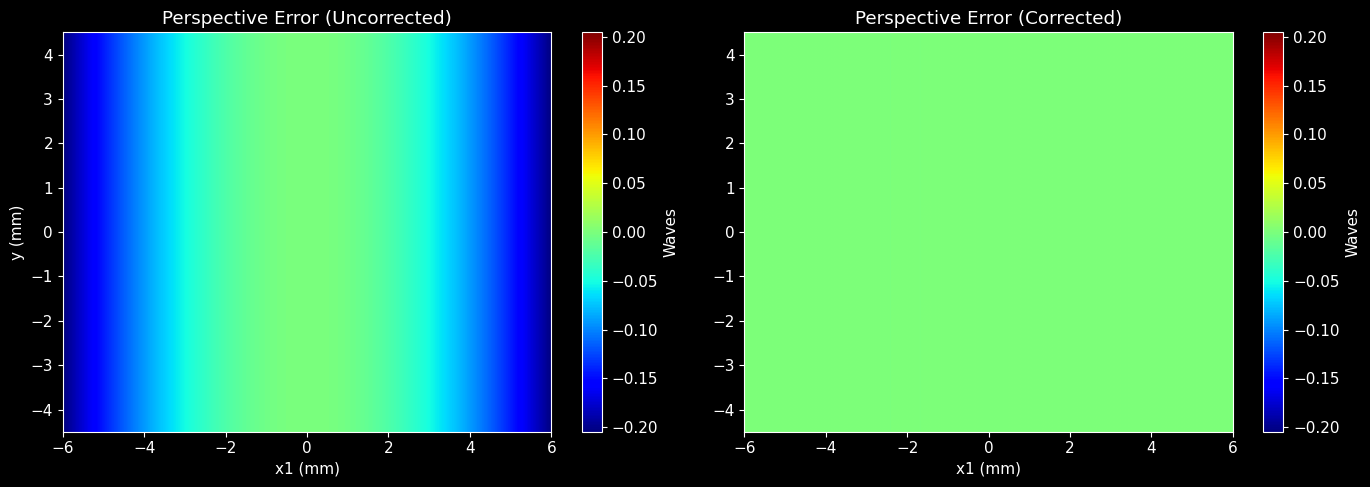

In [92]:
import matplotlib.pyplot as plt

error_uncorrected = (phi_uncorrected - phi_ideal) / (2 * np.pi)
error_corrected = (phi_corrected - phi_ideal) / (2 * np.pi)
ext = [-FOV/2, FOV/2, -FOV*Ny/(2*Nx), FOV*Ny/(2*Nx)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmax = np.max(np.abs(error_uncorrected))
c1 = ax1.imshow(error_uncorrected, cmap='jet', extent=ext, aspect='auto',
                vmin=-vmax, vmax=vmax)
plt.colorbar(c1, ax=ax1, label='Waves')
ax1.set_title('Perspective Error (Uncorrected)')
ax1.set_xlabel('x1 (mm)')
ax1.set_ylabel('y (mm)')

c2 = ax2.imshow(error_corrected, cmap='jet', extent=ext, aspect='auto',
                vmin=-vmax, vmax=vmax)
plt.colorbar(c2, ax=ax2, label='Waves')
ax2.set_title('Perspective Error (Corrected)')
ax2.set_xlabel('x1 (mm)')

plt.tight_layout()
plt.show()

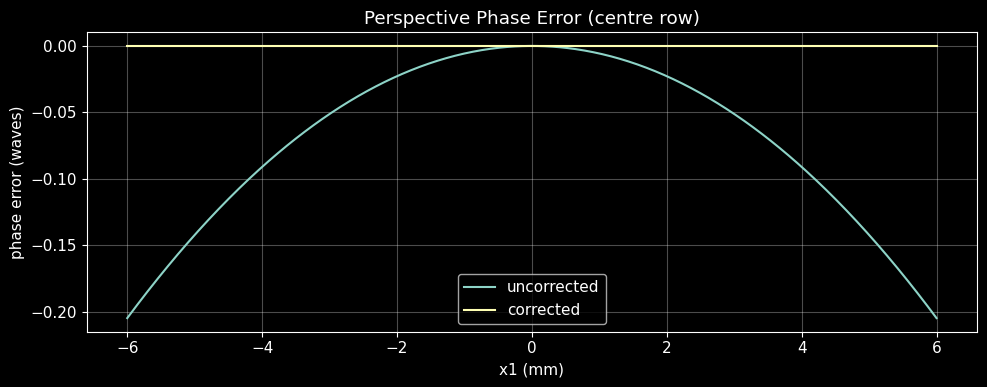

In [93]:
fig, ax = plt.subplots(figsize=(10, 4))
mid = Ny // 2
ax.plot(x1_mm, error_uncorrected[mid, :], label='uncorrected')
ax.plot(x1_mm, error_corrected[mid, :], label='corrected')
ax.set_xlabel('x1 (mm)')
ax.set_ylabel('phase error (waves)')
ax.set_title('Perspective Phase Error (centre row)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Custom Grating Visualization

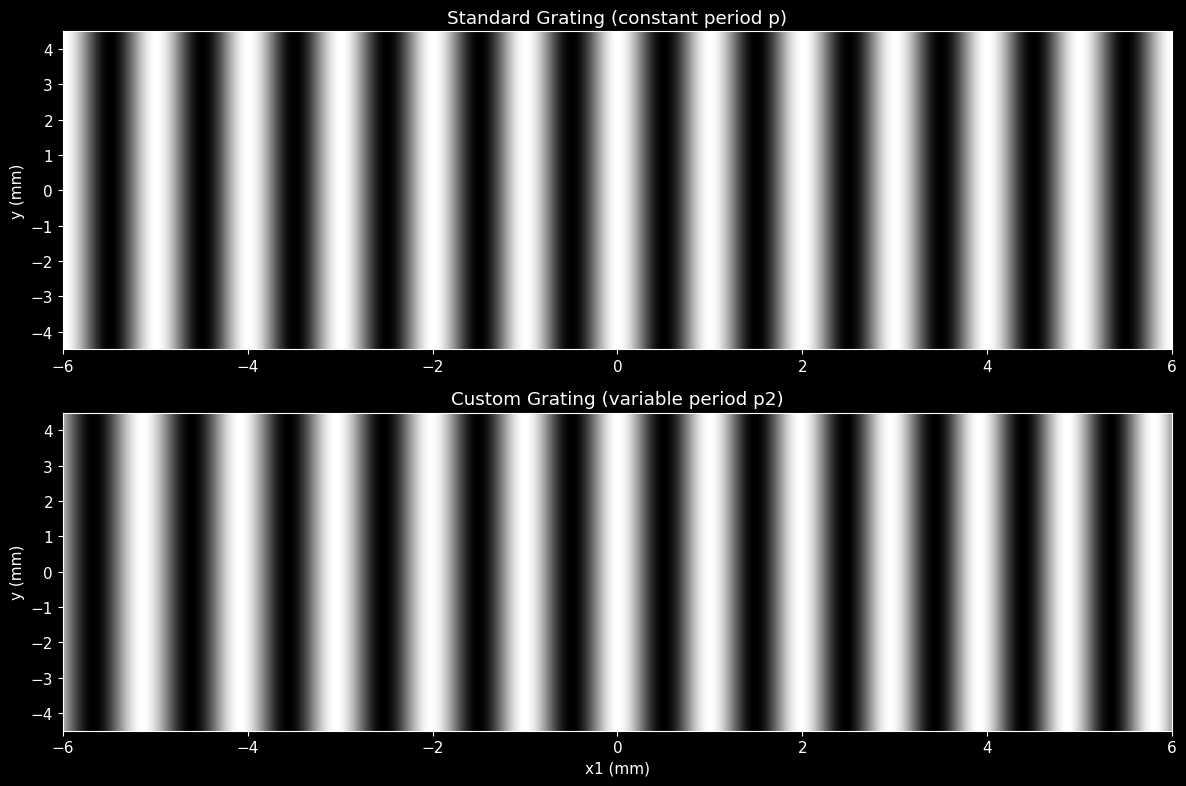

In [94]:
I_standard = A + B * np.cos(2 * np.pi * X1 / p)
I_custom = A + B * np.cos(2 * np.pi * X1 / p2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.imshow(I_standard, cmap='gray', vmin=0, vmax=1, extent=ext, aspect='auto')
ax1.set_title('Standard Grating (constant period p)')
ax1.set_ylabel('y (mm)')

ax2.imshow(I_custom, cmap='gray', vmin=0, vmax=1, extent=ext, aspect='auto')
ax2.set_title('Custom Grating (variable period p2)')
ax2.set_xlabel('x1 (mm)')
ax2.set_ylabel('y (mm)')

plt.tight_layout()
plt.show()

## Quantitative Summary

In [95]:
pv_error = np.ptp(error_uncorrected)
rms_error = np.std(error_uncorrected)
lambda_eq = M * p / (2 * np.sin(theta))

print('standard grating:')
print(f'PV phase error: {pv_error:.4f} waves')
print(f'RMS phase error: {rms_error:.4f} waves')
print(f'apparent PV height: {pv_error * lambda_eq * 1000:.2f} um')
print()

print('custom grating:')
print(f'PV phase error: {np.ptp(error_corrected):.2e} waves')
print()

print('system:')
print(f'equivalent wavelength: {lambda_eq:.4f} mm')
print(f'magnification M: {M:.2f}')
print(f'perspective factor range: [{perspective.min():.4f}, {perspective.max():.4f}]')

standard grating:
PV phase error: 0.2047 waves
RMS phase error: 0.0612 waves
apparent PV height: 299.30 um

custom grating:
PV phase error: 8.48e-16 waves

system:
equivalent wavelength: 1.4619 mm
magnification M: 1.00
perspective factor range: [0.9659, 1.0341]
